In [1]:
# ============================================================
# PS6.4 — SABR Calibration + comparison against SVI
# ============================================================
# Reads the clean snapshot CSV built in the previous step:
#   snapshot_2026-05-26_exp2026-05-29.csv
# Columns: strike, type, tau, price_btc, n_trades, iv,
#          log_moneyness, spot_used, snapshot_date, expiry_date
# ============================================================

import numpy as np
import pandas as pd
import torch

torch.manual_seed(42)
np.random.seed(42)

SNAPSHOT_CSV = 'snapshot_2026-05-26_exp2026-05-29.csv'

# ------------------------------------------------------------
# 1. Load
# ------------------------------------------------------------
snap = pd.read_csv(SNAPSHOT_CSV)
F = float(snap['spot_used'].iloc[0])          # forward proxy (r=0 simplification)
tau = float(snap['tau'].iloc[0])
strikes = snap['strike'].values
ivs = snap['iv'].values
print(f"Loaded snapshot: {len(snap)} strikes, F={F:.0f}, tau={tau:.5f} yrs "
      f"({snap['snapshot_date'].iloc[0]} -> {snap['expiry_date'].iloc[0]})")

if len(snap) < 5:
    raise ValueError("Fewer than 5 points — SABR/SVI fits will be poorly constrained. "
                      "Loosen min_trades or pick a busier snapshot.")

# ------------------------------------------------------------
# 2. SABR — Hagan lognormal approximation, beta fixed at 1
#    (beta=1 is the standard convention for crypto: crypto vol scales
#    roughly log-normally with price, similar to FX, rather than the
#    beta=0 normal-vol convention common in rates markets)
# ------------------------------------------------------------
def sabr_vol_batch(F, K, tau, alpha, beta, rho, nu):
    """Vectorized Hagan SABR, torch tensors. K is a vector; F, alpha, rho, nu are scalars."""
    eps = 1e-7
    logFK = torch.log(F / K)
    FK_beta = (F * K) ** ((1 - beta) / 2)

    z = (nu / alpha) * FK_beta * logFK
    # numerically safe near z=0 (ATM): x(z)/z -> 1 as z -> 0
    sqrt_term = torch.sqrt(1 - 2 * rho * z + z ** 2)
    x_z = torch.log((sqrt_term + z - rho) / (1 - rho) + eps)
    z_over_xz = torch.where(torch.abs(z) < 1e-6, torch.ones_like(z), z / (x_z + eps))

    term1 = alpha / (FK_beta * (1 + (1 - beta) ** 2 / 24 * logFK ** 2
                                 + (1 - beta) ** 4 / 1920 * logFK ** 4))
    term3 = 1 + tau * ((1 - beta) ** 2 / 24 * alpha ** 2 / (FK_beta ** 2 + eps)
                        + 0.25 * rho * beta * nu * alpha / (FK_beta + eps)
                        + (2 - 3 * rho ** 2) / 24 * nu ** 2)
    return term1 * z_over_xz * term3


def calibrate_sabr(strikes, ivs, F, tau, beta=1.0, n_steps=3000, lr=0.03):
    K = torch.tensor(strikes, dtype=torch.float32)
    market_iv = torch.tensor(ivs, dtype=torch.float32)
    Ft = torch.tensor(F, dtype=torch.float32)

    log_alpha = torch.tensor(float(np.log(market_iv.mean().item())), requires_grad=True)
    rho_raw = torch.zeros(1, requires_grad=True)
    log_nu = torch.zeros(1, requires_grad=True)

    opt = torch.optim.Adam([log_alpha, rho_raw, log_nu], lr=lr)
    losses = []
    for step in range(n_steps):
        alpha = torch.exp(log_alpha)
        rho = torch.tanh(rho_raw)
        nu = torch.exp(log_nu)
        model_iv = sabr_vol_batch(Ft, K, tau, alpha, beta, rho, nu)
        loss = ((model_iv - market_iv) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())

    alpha_f = torch.exp(log_alpha).item()
    rho_f = torch.tanh(rho_raw).item()
    nu_f = torch.exp(log_nu).item()
    with torch.no_grad():
        model_iv_final = sabr_vol_batch(Ft, K, tau, torch.tensor(alpha_f), beta,
                                         torch.tensor(rho_f), torch.tensor(nu_f))
        residuals = (model_iv_final - market_iv).numpy()
    rmse = float(np.sqrt((residuals ** 2).mean()))
    return {'alpha': alpha_f, 'beta': beta, 'rho': rho_f, 'nu': nu_f,
            'rmse_vol_units': rmse, 'residuals': residuals, 'model_iv': model_iv_final.numpy(),
            'converged': losses[-1] < losses[0]}


# ------------------------------------------------------------
# 3. Raw SVI — for the required quantitative comparison.
#    (If your teammate has already fit SVI on this exact snapshot,
#     use THEIR params/RMSE instead of this — see note at bottom.)
# ------------------------------------------------------------
def raw_svi(k, a, b, rho, m, sigma):
    return a + b * (rho * (k - m) + torch.sqrt((k - m) ** 2 + sigma ** 2))

def calibrate_svi(strikes, ivs, F, tau, n_steps=4000, lr=0.01):
    k = torch.tensor(np.log(np.array(strikes) / F), dtype=torch.float32)
    w_mkt = torch.tensor((np.array(ivs) ** 2) * tau, dtype=torch.float32)

    a = torch.tensor(float(w_mkt.mean().item()), requires_grad=True)
    b_raw = torch.tensor(0.1, requires_grad=True)
    rho_raw = torch.zeros(1, requires_grad=True)
    m = torch.zeros(1, requires_grad=True)
    log_sigma = torch.zeros(1, requires_grad=True)

    opt = torch.optim.Adam([a, b_raw, rho_raw, m, log_sigma], lr=lr)
    for step in range(n_steps):
        rho = torch.tanh(rho_raw)
        sigma = torch.exp(log_sigma)
        b_pos = torch.nn.functional.softplus(b_raw)
        w_model = raw_svi(k, a, b_pos, rho, m, sigma)
        loss = ((w_model - w_mkt) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()

    with torch.no_grad():
        b_pos = torch.nn.functional.softplus(b_raw)
        rho = torch.tanh(rho_raw)
        sigma = torch.exp(log_sigma)
        w_final = raw_svi(k, a, b_pos, rho, m, sigma)
        iv_model = torch.sqrt(torch.clamp(w_final / tau, min=1e-6))
        residuals = (iv_model - torch.tensor(ivs, dtype=torch.float32)).numpy()
    rmse = float(np.sqrt((residuals ** 2).mean()))
    return {'a': a.item(), 'b': b_pos.item(), 'rho': rho.item(), 'm': m.item(),
            'sigma': sigma.item(), 'rmse_vol_units': rmse, 'residuals': residuals,
            'model_iv': iv_model.numpy()}


# ------------------------------------------------------------
# 4. Run both, compare
# ------------------------------------------------------------
sabr = calibrate_sabr(strikes, ivs, F, tau)
svi = calibrate_svi(strikes, ivs, F, tau)

print("\n=== SABR fit (beta fixed at 1.0) ===")
for k in ['alpha', 'beta', 'rho', 'nu', 'rmse_vol_units']:
    print(f"  {k}: {sabr[k]:.6f}")
print(f"  converged: {sabr['converged']}")

print("\n=== SVI fit ===")
for k in ['a', 'b', 'rho', 'm', 'sigma', 'rmse_vol_units']:
    print(f"  {k}: {svi[k]:.6f}")

print(f"\n{'Strike':>8} {'Type':>5} {'Market IV':>10} {'SABR IV':>10} {'SABR resid':>11} {'SVI IV':>10} {'SVI resid':>10}")
for i in range(len(snap)):
    print(f"{strikes[i]:>8.0f} {snap['type'].iloc[i]:>5} {ivs[i]:>10.4f} "
          f"{sabr['model_iv'][i]:>10.4f} {sabr['residuals'][i]:>11.4f} "
          f"{svi['model_iv'][i]:>10.4f} {svi['residuals'][i]:>10.4f}")

print(f"\nSABR RMSE: {sabr['rmse_vol_units']:.5f}   |   SVI RMSE: {svi['rmse_vol_units']:.5f}")
better = "SABR" if sabr['rmse_vol_units'] < svi['rmse_vol_units'] else "SVI"
print(f"Better in-sample fit: {better}")

# ------------------------------------------------------------
# 5. Save results for the write-up / plotting
# ------------------------------------------------------------
out = snap.copy()
out['sabr_iv'] = sabr['model_iv']
out['sabr_resid'] = sabr['residuals']
out['svi_iv'] = svi['model_iv']
out['svi_resid'] = svi['residuals']
out.to_csv('sabr_vs_svi_comparison.csv', index=False)
print("\nSaved sabr_vs_svi_comparison.csv")

Loaded snapshot: 33 strikes, F=75974, tau=0.00822 yrs (2026-05-26 -> 2026-05-29)

=== SABR fit (beta fixed at 1.0) ===
  alpha: 0.240593
  beta: 1.000000
  rho: -0.262762
  nu: 10.601859
  rmse_vol_units: 0.032548
  converged: True

=== SVI fit ===
  a: -0.358816
  b: 0.579455
  rho: 0.516552
  m: 0.417300
  sigma: 0.722989
  rmse_vol_units: 0.198555

  Strike  Type  Market IV    SABR IV  SABR resid     SVI IV  SVI resid
   58000     P     1.1116     1.0325     -0.0792     1.2811     0.1694
   60000     P     0.9839     0.9445     -0.0394     1.1184     0.1345
   66000     P     0.6174     0.6832      0.0658     0.6403     0.0229
   68000     P     0.5446     0.5956      0.0510     0.4829    -0.0617
   70000     P     0.4650     0.5069      0.0419     0.3244    -0.1406
   71000     P     0.4262     0.4620      0.0359     0.2431    -0.1830
   72000     P     0.3932     0.4168      0.0236     0.1570    -0.2362
   72500     P     0.3764     0.3941      0.0178     0.1083    -0.2681
   7300

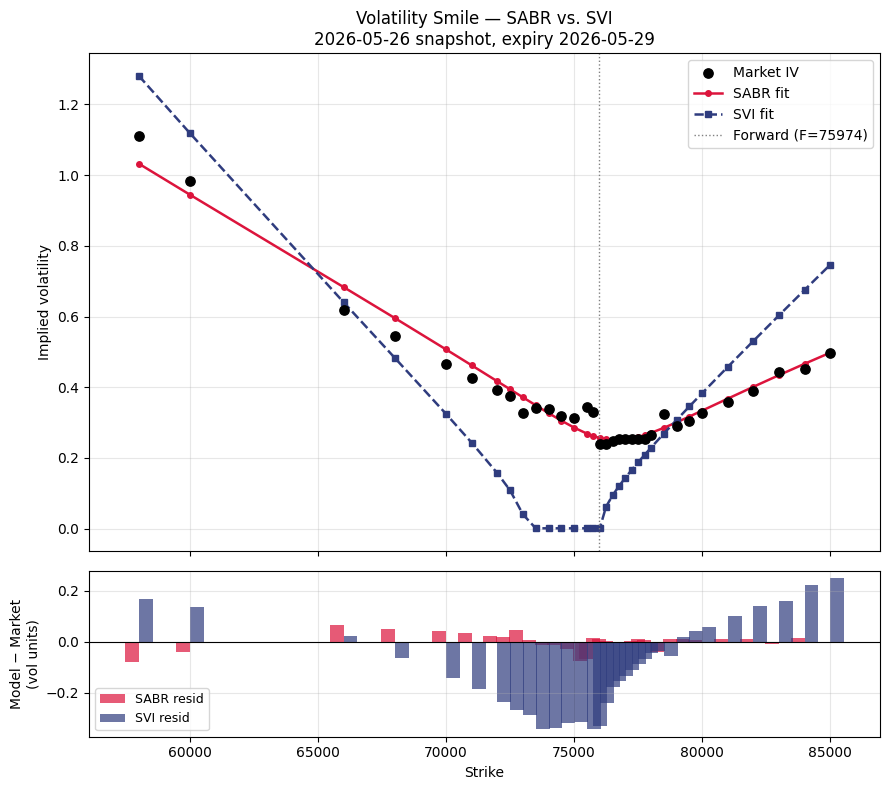

Saved sabr_vs_svi_smile.png


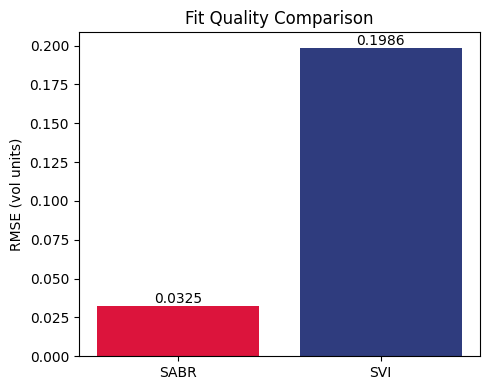

Saved sabr_vs_svi_rmse.png


In [2]:
# ============================================================
# PS6.4 — Visualize SABR vs SVI fit against market IVs
# Run AFTER ps6_4_run.py (reads sabr_vs_svi_comparison.csv)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('sabr_vs_svi_comparison.csv')
df = df.sort_values('strike').reset_index(drop=True)

F = df['spot_used'].iloc[0]
snapshot_date = df['snapshot_date'].iloc[0]
expiry_date = df['expiry_date'].iloc[0]

fig, axes = plt.subplots(2, 1, figsize=(9, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# ---- Top panel: smile ----
ax = axes[0]
ax.scatter(df['strike'], df['iv'], color='black', zorder=5, label='Market IV', s=45)
ax.plot(df['strike'], df['sabr_iv'], color='crimson', marker='o', markersize=4,
        linewidth=1.8, label='SABR fit')
ax.plot(df['strike'], df['svi_iv'], color='#2F3C7E', marker='s', markersize=4,
        linewidth=1.8, linestyle='--', label='SVI fit')
ax.axvline(F, color='gray', linestyle=':', linewidth=1, label=f'Forward (F={F:.0f})')
ax.set_ylabel('Implied volatility')
ax.set_title(f'Volatility Smile — SABR vs. SVI\n{snapshot_date} snapshot, expiry {expiry_date}')
ax.legend()
ax.grid(alpha=0.3)

# ---- Bottom panel: residuals ----
ax2 = axes[1]
width = (df['strike'].max() - df['strike'].min()) * 0.01
ax2.bar(df['strike'] - width, df['sabr_resid'], width=width*2, color='crimson', alpha=0.7, label='SABR resid')
ax2.bar(df['strike'] + width, df['svi_resid'], width=width*2, color='#2F3C7E', alpha=0.7, label='SVI resid')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Strike')
ax2.set_ylabel('Model \u2212 Market\n(vol units)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('sabr_vs_svi_smile.png', dpi=150)
plt.show()
print("Saved sabr_vs_svi_smile.png")

# ------------------------------------------------------------
# Optional second figure: RMSE bar comparison (useful as a
# single summary slide/figure for the report)
# ------------------------------------------------------------
sabr_rmse = np.sqrt((df['sabr_resid'] ** 2).mean())
svi_rmse = np.sqrt((df['svi_resid'] ** 2).mean())

fig2, ax3 = plt.subplots(figsize=(5, 4))
bars = ax3.bar(['SABR', 'SVI'], [sabr_rmse, svi_rmse], color=['crimson', '#2F3C7E'])
ax3.set_ylabel('RMSE (vol units)')
ax3.set_title('Fit Quality Comparison')
for b, v in zip(bars, [sabr_rmse, svi_rmse]):
    ax3.text(b.get_x() + b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('sabr_vs_svi_rmse.png', dpi=150)
plt.show()
print("Saved sabr_vs_svi_rmse.png")